(ch:mcmc)=
# 6. Markov chain Monte Carlo

```{admonition} Goals of this chapter
:class: note
After working through this chapter you should be able to

* explain why we want *samples* from the posterior rather than the posterior on a grid, and what a Markov chain is;
* write down and implement the Metropolis–Hastings algorithm, and diagnose a chain: burn-in, acceptance rate, autocorrelation;
* explain the idea behind the affine-invariant ensemble sampler of `emcee`, and use `emcee` to sample a posterior;
* turn posterior samples into credible intervals, corner plots and error propagation, and compare with the bootstrap.

This chapter accompanies the second part of Lecture 5 and Lecture 6. The photon-counts dataset of Chapters 1 and 4 returns one last time. The MCMC part of the hand-in assignment uses exactly the tools introduced here.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize
import emcee, corner

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

# the photon-counts dataset of Chapters 1 and 4 (same seed, same data); used in Section 6.5
rng_data = np.random.default_rng(8)
N = 100
mu_true, eps_true = 1000, 15
F_true = rng_data.normal(mu_true, eps_true, size=N)
y = rng_data.poisson(F_true)
sigma_y = np.sqrt(y)

rng = np.random.default_rng(6)          # a separate generator for the samplers in this chapter
np.random.seed(6)                       # emcee draws from numpy's global random state

## 6.1 Why sampling?

The third step of Bayesian inference is to compute the posterior $p(\theta\,|\,y) \propto p(\theta)\,p(y\,|\,\theta)$. In Chapter 4 we did this on a grid. Two problems appear as soon as the model has more than two or three parameters.

1. **A grid is slow.** With $M$ grid points per parameter and $k$ parameters we need $M^k$ likelihood evaluations. For $M=100$ and $k=6$ that is $10^{12}$.
2. **Marginalization on a grid is awkward.** To get the marginal posterior of one parameter we must sum the grid over all the others, and to get credible intervals we must integrate the marginals.

Both problems disappear if, instead of the *value* of the posterior on a grid, we have a set of **samples** $\{\theta^{(1)}, \theta^{(2)}, \dots, \theta^{(T)}\}$ drawn from the posterior: parameter vectors that appear with a frequency proportional to $p(\theta\,|\,y)$. Then

* the histogram of the samples of $\theta_1$ *is* the marginal posterior $p(\theta_1\,|\,y)$ (the other parameters have been marginalized over automatically, because every sample carries a value for each of them);
* credible intervals are percentiles of the samples;
* the posterior of any derived quantity $g(\theta)$ is obtained by evaluating $g$ on the samples: error propagation for free;
* the cost scales roughly linearly with the number of parameters, not exponentially.

The question is how to draw samples from a distribution that we can only evaluate up to a normalization constant. The answer is Markov chain Monte Carlo (MCMC).

## 6.2 Markov chains

We want a sequence of random variables $\Theta_0, \Theta_1, \dots, \Theta_T$ whose distribution, after some initial transient, is the posterior. Such a sequence can be constructed as a **Markov chain**: each element depends only on the previous one,

$$
p(\Theta_{t+1}\,|\,\Theta_t, \Theta_{t-1}, \dots, \Theta_0) = p(\Theta_{t+1}\,|\,\Theta_t) .
$$ (eq:markov)

"What comes next is determined entirely by the present state." The consecutive elements of the chain are therefore *correlated*, not independent draws, but Markov (1906) proved that the law of large numbers still holds: for $T\to\infty$ the sample mean of the chain converges to the mean of the distribution it explores. If we design the transition rule such that the chain's stationary distribution is the posterior, the elements of the chain are the samples we want.

## 6.3 The Metropolis–Hastings algorithm

The simplest rule that does this is the Metropolis algorithm (1953), generalized by Hastings (1970). It is a random walk through parameter space with a rule for accepting or rejecting each step.

```{admonition} The Metropolis–Hastings algorithm
:class: important
0. Start somewhere: choose $\theta_0$ (with $p(\theta_0\,|\,y) > 0$). This is the first element of the chain.
1. **Propose** a candidate $\theta'$ for the next element by drawing from a *proposal distribution* $Q(\theta'\,|\,\theta_t)$, for example a Gaussian centred on the current position: $\theta' = \theta_t + \mathcal{N}(0, s^2)$.
2. Compute the **ratio of posterior densities** at the proposed and the current position,
   $$
   r = \frac{p(\theta'\,|\,y)}{p(\theta_t\,|\,y)} .
   $$
   Only the ratio is needed, so the normalization of the posterior (the evidence) drops out: unnormalized posteriors are fine.
3. **Accept or reject.** Draw $u$ uniformly from $[0, 1]$. If $u < r$, accept: $\theta_{t+1} = \theta'$. Otherwise reject: $\theta_{t+1} = \theta_t$ (the current position is *repeated* in the chain).
4. Go to step 1.
```

So a proposal that *increases* the posterior ($r > 1$) is always accepted, and a proposal that decreases it is accepted with probability $r$. The chain therefore spends most of its time where the posterior is high, but occasionally wanders into the tails, in exactly the right proportion. If the proposal distribution is symmetric, $Q(\theta'\,|\,\theta) = Q(\theta\,|\,\theta')$, this is the Metropolis algorithm. For an asymmetric proposal (e.g. one that can only propose positive values), Hastings' correction is needed:

$$
r = \frac{p(\theta'\,|\,y)}{p(\theta_t\,|\,y)}\;\frac{Q(\theta_t\,|\,\theta')}{Q(\theta'\,|\,\theta_t)} .
$$ (eq:mh-ratio)

In practice we work with logarithms: compute $\ln r = \ln p(\theta'\,|\,y) - \ln p(\theta_t\,|\,y)$ and accept if $\ln u < \ln r$.

### Speedrun: one parameter, one chain

The example from the lecture. Data $y = [1, 2, 3]$ with $\sigma_y = [1,1,1]$; we want the mean $\mu$. With a flat prior the posterior is the Gaussian likelihood, $p(\mu\,|\,y) \propto \exp[-\sum_i (y_i-\mu)^2/2]$, and we know the answer: $\mu = 2 \pm 1/\sqrt{3} = 2 \pm 0.577$.

acceptance fraction 0.54;  chain mean 2.024, std 0.586  (expected 2.000, 0.577)


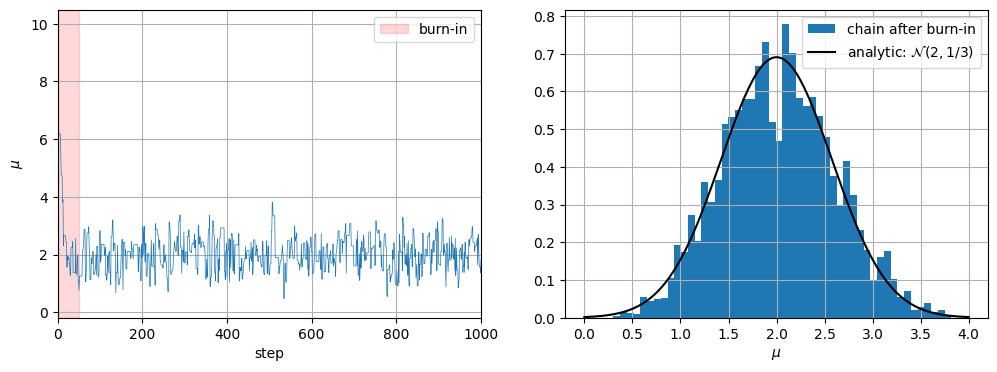

In [2]:
y_speed = np.array([1.0, 2.0, 3.0])
sigma_speed = np.array([1.0, 1.0, 1.0])

def log_post_speed(mu):
    """log posterior for the mean of y (flat prior, Gaussian likelihood)"""
    return -0.5 * np.sum((y_speed - mu)**2 / sigma_speed**2)

def metropolis(log_post, theta0, n_steps, proposal_width, rng):
    """Metropolis algorithm with a Gaussian proposal; returns the chain and the acceptance fraction"""
    chain = np.zeros(n_steps)
    theta, lp = theta0, log_post(theta0)
    n_accept = 0
    for t in range(n_steps):
        theta_prop = theta + rng.normal(0, proposal_width)          # step 1: propose
        lp_prop = log_post(theta_prop)
        if np.log(rng.uniform()) < lp_prop - lp:                    # steps 2+3: accept with probability min(1, r)
            theta, lp = theta_prop, lp_prop
            n_accept += 1
        chain[t] = theta                                            # (rejected: the old value is repeated)
    return chain, n_accept / n_steps

chain, acc = metropolis(log_post_speed, theta0=10.0, n_steps=5000, proposal_width=1.0, rng=rng)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(chain, lw=0.5); axs[0].axvspan(0, 50, color="red", alpha=0.15, label="burn-in")
axs[0].set_xlabel("step"); axs[0].set_ylabel(r"$\mu$"); axs[0].set_xlim(0, 1000); axs[0].legend()
burn = 50
axs[1].hist(chain[burn:], bins=50, density=True, label="chain after burn-in")
mm = np.linspace(0, 4, 200)
axs[1].plot(mm, stats.norm.pdf(mm, 2, 1/np.sqrt(3)), "k", label=r"analytic: $\mathcal{N}(2, 1/3)$")
axs[1].set_xlabel(r"$\mu$"); axs[1].legend()
print(f"acceptance fraction {acc:.2f};  chain mean {chain[burn:].mean():.3f}, std {chain[burn:].std():.3f}  (expected 2.000, 0.577)")

Fifteen lines of code, and the histogram of the chain reproduces the posterior. Note the two phases in the trace: the chain starts far away (at $\mu_0 = 10$), walks towards the region of high posterior probability in a few dozen steps, and then fluctuates around it. The first phase is called the **burn-in**; those samples are not drawn from the posterior and must be discarded before making histograms.

### Tuning the proposal: acceptance rate and autocorrelation

The width $s$ of the proposal distribution is the one knob of the algorithm, and it matters.

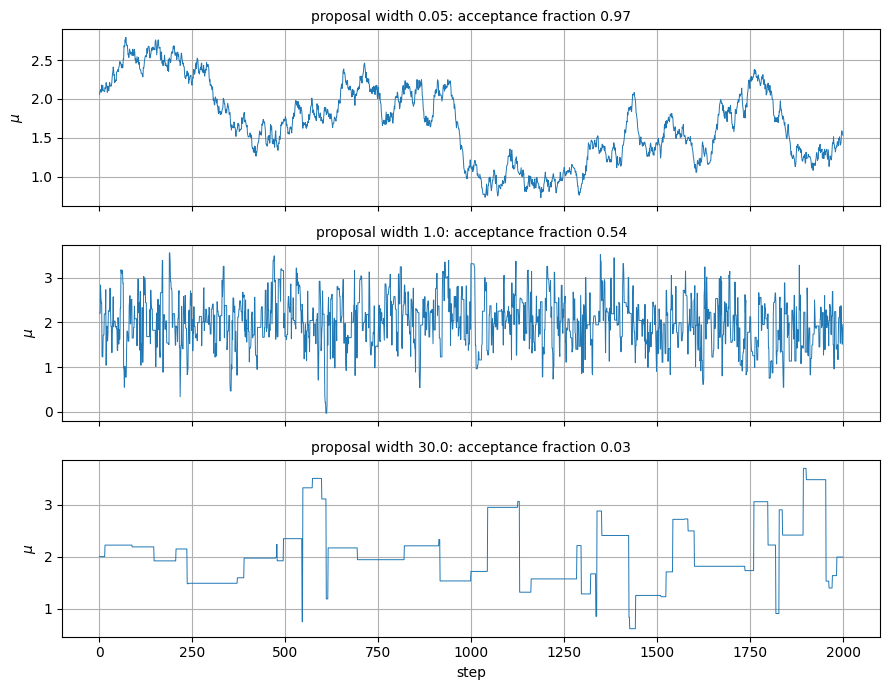

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, width in zip(axs, [0.05, 1.0, 30.0]):
    ch, acc = metropolis(log_post_speed, theta0=2.0, n_steps=2000, proposal_width=width, rng=rng)
    ax.plot(ch, lw=0.7); ax.set_ylabel(r"$\mu$")
    ax.set_title(f"proposal width {width}: acceptance fraction {acc:.2f}", fontsize=10)
axs[-1].set_xlabel("step"); plt.tight_layout()

* A **too small** step (top) is almost always accepted, but the chain creeps along and takes forever to explore the posterior; consecutive samples are nearly identical.
* A **too large** step (bottom) proposes mostly absurd values that are rejected; the chain stays stuck at the same value for long stretches.
* In between (middle), the chain mixes well. For a one-dimensional Gaussian posterior the optimal proposal width is about $2.4$ times the posterior width, giving an acceptance rate of $\approx 0.44$; for many parameters the optimum drops to $\approx 0.23$. Rule of thumb: an acceptance fraction between $0.2$ and $0.6$ is healthy; values close to 0 or 1 mean the proposal needs tuning.

The quantitative diagnostic is the **autocorrelation** of the chain. The autocorrelation coefficient at lag $\ell$,

$$
\rho(\ell) = \frac{\sum_{t=1}^{T-\ell}(\theta_t - \bar\theta)(\theta_{t+\ell}-\bar\theta)}{\sum_{t=1}^{T}(\theta_t-\bar\theta)^2} ,
$$ (eq:autocorr)

measures how similar samples $\ell$ steps apart are. The **integrated autocorrelation time** $\tau = 1 + 2\sum_{\ell\geq1}\rho(\ell)$ is the number of steps between effectively independent samples, so a chain of length $T$ contains only about $T/\tau$ independent samples. A well-tuned chain has a short $\tau$; you should run for at least $\sim 50\tau$ steps, and discard a burn-in of a few $\tau$.

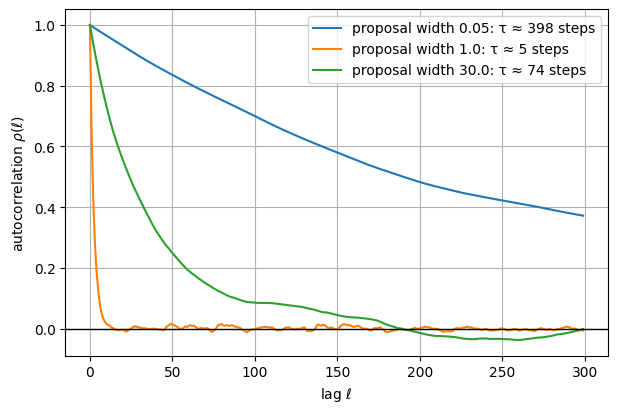

In [4]:
def autocorr(chain, max_lag):
    x = chain - chain.mean()
    return np.array([np.sum(x[:len(x)-lag] * x[lag:]) / np.sum(x**2) for lag in range(max_lag)])

fig, ax = plt.subplots()
for width in [0.05, 1.0, 30.0]:
    ch, _ = metropolis(log_post_speed, theta0=2.0, n_steps=50000, proposal_width=width, rng=rng)
    tau = emcee.autocorr.integrated_time(ch)[0]
    ax.plot(autocorr(ch, 300), label=f"proposal width {width}: τ ≈ {tau:.0f} steps")
ax.axhline(0, color="k", lw=1); ax.set_xlabel(r"lag $\ell$"); ax.set_ylabel(r"autocorrelation $\rho(\ell)$"); ax.legend();

### Find the bug

````{admonition} Hasty MCMC (exam 2025)
:class: tip
The code below was written (by a large language model) to sample the posterior of $\mu$ for 100 data points $y_i \sim \mathcal{N}(\mu=5, \sigma=2)$ with a flat prior; the correct posterior is $\mathcal{N}(\bar y, \sigma^2/N)$, with width $0.2$. The acceptance rate is 32%. The samples have the *right mean* but the *wrong width*. There is one bug. Find it, and explain why it leads to the wrong posterior samples.

```python
def log_likelihood(mu, sigma, data):
    ll = 0
    for x in data:
        ll -= (x - mu)**2 / (sigma**2)
    return ll

def metropolis_hastings(log_likelihood_func, data, n_iter=10000, proposal_std=0.5):
    current_mu = sum(data) / len(data)
    samples, accepted = [], 0
    for i in range(n_iter):
        proposed_mu = current_mu + random.gauss(0, proposal_std)
        log_ratio = (log_likelihood_func(proposed_mu, true_sigma, data) -
                     log_likelihood_func(current_mu, true_sigma, data))
        uni_r = math.log(random.random())     # log of a uniform draw in (0, 1)
        if uni_r < log_ratio:
            current_mu = proposed_mu
            accepted += 1
        samples.append(current_mu)
    return samples, accepted / n_iter
```

```{admonition} Answer
:class: dropdown
The log-likelihood misses the factor $\frac12$: it should be $-\sum_i (x_i-\mu)^2/(2\sigma^2)$. Without it the code samples $\exp[-\sum_i(x_i-\mu)^2/\sigma^2]$, a Gaussian in $\mu$ with variance $\sigma^2/2N$ instead of $\sigma^2/N$. The peak (the sample mean) is unaffected, but the sampled posterior is too narrow by a factor $\sqrt2$. The Metropolis part (log-ratio, comparison with $\ln u$, repeating the current value on rejection) is correct.

A related exam question: why is the peak of the *correct* posterior not exactly at $\mu_{\rm true}=5$? Because the posterior is centred on the sample mean $\bar y$, which for 100 points with $\sigma=2$ differs from the true mean by a random amount of order $\sigma/\sqrt N = 0.2$.
```
````

### Limitations of Metropolis–Hastings

For one or two parameters the algorithm is all you need. For more, the proposal distribution needs to be tuned in every dimension, and if the parameters are correlated (a long, thin, tilted posterior) a proposal with independent steps must be tiny to be accepted, and the chain crawls. One can transform the parameters or use a multivariate proposal with the right covariance, but that requires knowing the covariance of the posterior, which is what we are trying to find. Hence the popularity of samplers that adapt themselves.

## 6.4 Ensemble samplers and `emcee`

The sampler used by most astronomers today is `emcee` (Foreman-Mackey et al. 2013), an implementation of the *affine-invariant ensemble sampler* of Goodman & Weare (2010).

**Affine invariance.** An affine transformation is a linear map plus a shift, $\theta \to A\theta + b$: stretching, rotating and translating parameter space. A long, thin, tilted Gaussian is the affine image of a round one. An *affine-invariant* sampler performs identically on both, so it does not care about correlations between parameters or about their scales, and needs no tuning of a proposal covariance.

**The stretch move.** Instead of one chain, use an *ensemble* of $K$ walkers $\{\theta_1, \dots, \theta_K\}$ that explore the posterior together. To update walker $i$, pick another walker $j$ at random and propose a point on the line connecting them:

$$
\theta_i' = \theta_j + z\,(\theta_i - \theta_j) , \qquad z \sim g(z) \propto \frac{1}{\sqrt z}\ \text{on}\ [1/a, a] ,
$$ (eq:stretch)

so the proposal is a random *stretch* of the current displacement between two walkers. The proposal is accepted with probability $\min(1,\, z^{k-1}\, p(\theta_i'\,|\,y)/p(\theta_i\,|\,y))$ (the factor $z^{k-1}$, with $k$ the number of parameters, is the Hastings correction for this move). Because the walkers themselves have spread out over the posterior, the proposals automatically have the right scale and orientation. The only tuning parameter is $a$ (default 2). In `emcee` the ensemble is split into two halves that are updated alternately, which allows the likelihood evaluations to run in parallel.

**Using `emcee`.** You supply a function that returns the log-posterior (log-prior plus log-likelihood, $-\infty$ where the prior is zero), the number of walkers (a few times the number of parameters; 32 is a common minimum), and a starting position for every walker, typically a small ball around the maximum-likelihood solution. Then you run, look at the chains, discard the burn-in, and analyse the samples.

## 6.5 Worked example: mean and intrinsic scatter of the photon counts

We sample the posterior of $(\mu, \epsilon)$ for the photon-counts data, which we computed on a grid in Chapter 4, so we can check the result. The likelihood is Eq. {eq}`eq:loglike-eps`, the priors are flat with $\epsilon \geq 0$.

In [5]:
def log_likelihood(theta, y, sigma_y):
    mu, eps = theta
    s2 = sigma_y**2 + eps**2
    return -0.5 * np.sum(np.log(2 * np.pi * s2) + (y - mu)**2 / s2)

def log_prior(theta):
    mu, eps = theta
    if eps < 0 or not (0 < mu < 1e4):       # flat priors: eps must be positive, mu within a generous range
        return -np.inf
    return 0.0

def log_posterior(theta, y, sigma_y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, y, sigma_y)

# start the walkers in a small ball around the maximum-likelihood solution
theta_ml = optimize.minimize(lambda th: -log_posterior(th, y, sigma_y), x0=[900, 5], method="Nelder-Mead").x
n_walkers, n_dim = 32, 2
p0 = theta_ml + np.array([1.0, 1.0]) * rng.normal(size=(n_walkers, n_dim))
p0[:, 1] = np.abs(p0[:, 1])                # keep eps positive

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(y, sigma_y))
sampler.run_mcmc(p0, 3000, progress=False);

### Inspect the chains

integrated autocorrelation time: mu 32 steps, eps 30 steps
mean acceptance fraction of the walkers: 0.71


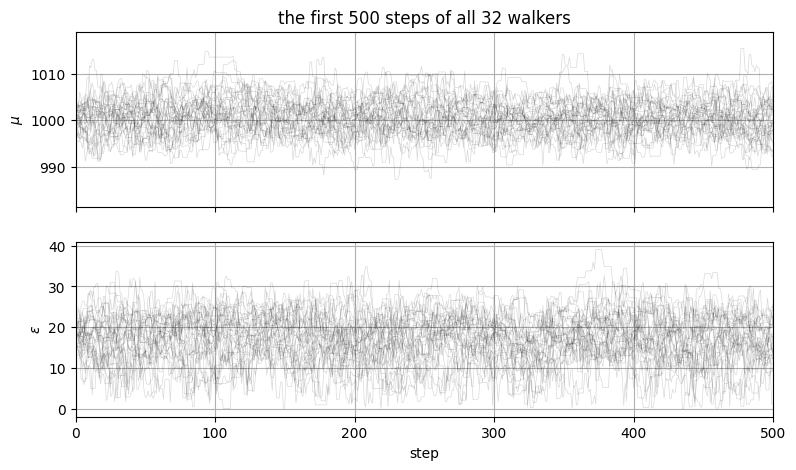

In [6]:
chain = sampler.get_chain()               # shape (n_steps, n_walkers, n_dim)
fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for i, (ax, name) in enumerate(zip(axs, [r"$\mu$", r"$\epsilon$"])):
    ax.plot(chain[:, :, i], color="k", alpha=0.15, lw=0.5)
    ax.set_ylabel(name); ax.set_xlim(0, 500)
axs[-1].set_xlabel("step"); axs[0].set_title("the first 500 steps of all 32 walkers");

tau = sampler.get_autocorr_time()
print(f"integrated autocorrelation time: mu {tau[0]:.0f} steps, eps {tau[1]:.0f} steps")
print(f"mean acceptance fraction of the walkers: {np.mean(sampler.acceptance_fraction):.2f}")

The walkers start in a tight ball and spread out over the posterior within a few dozen steps; after that the ensemble is stationary. The acceptance fraction of $\approx 0.7$ is higher than for our Metropolis chains, which is normal for the stretch move on a simple, nearly Gaussian posterior; in `emcee` it is the *low* values ($\lesssim 0.2$) that signal trouble. The autocorrelation time tells us how many steps to discard as burn-in (a few $\tau$) and how much to thin the chain (about $\tau/2$) to obtain roughly independent samples. Check also the acceptance fraction *per walker* (`sampler.acceptance_fraction`): a walker with a much lower acceptance than the others is stuck somewhere (a local maximum, or outside the prior range) and should be discarded.

In [7]:
samples = sampler.get_chain(discard=int(3 * tau.max()), thin=int(tau.max() / 2), flat=True)
print(f"{len(samples)} (approximately independent) posterior samples")

6176 (approximately independent) posterior samples


### Posterior summaries

The samples can now be used directly. The corner plot shows all one- and two-dimensional marginal posteriors at once; the percentiles give the credible intervals.

mu  =  1000.4 -3.7 +3.7   (95.4%: 993.0 to 1007.7)
eps =    17.8 -6.2 +5.3   (95.4%: 3.7 to 28.6)


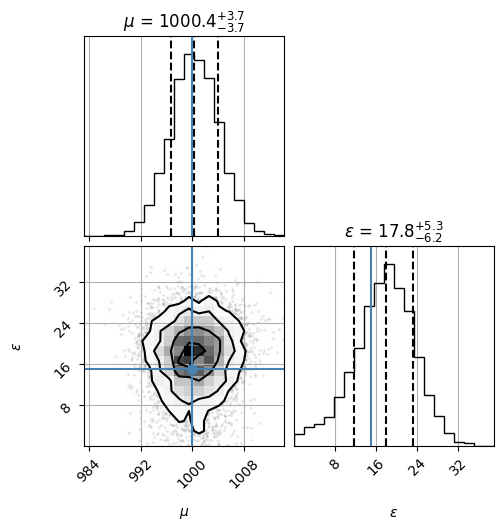

In [8]:
fig = corner.corner(samples, labels=[r"$\mu$", r"$\epsilon$"], truths=[mu_true, eps_true],
                    quantiles=[0.159, 0.5, 0.841], show_titles=True, title_fmt=".1f")

for i, name in enumerate(["mu", "eps"]):
    lo, med, hi = np.percentile(samples[:, i], [15.9, 50, 84.1])
    lo95, hi95 = np.percentile(samples[:, i], [2.3, 97.7])
    print(f"{name:3s} = {med:7.1f} -{med-lo:.1f} +{hi-med:.1f}   (95.4%: {lo95:.1f} to {hi95:.1f})")

These numbers agree with the grid calculation of Chapter 4, as they must; and the 95% interval of $\epsilon$ again only just excludes zero. The MCMC took a couple of seconds; the grid took about the same for two parameters, but the grid would take a thousand times longer for four parameters, and the MCMC would not.

### Error propagation with samples

Any function of the parameters inherits a posterior from the samples. Suppose we want the *fractional* variability $\epsilon/\mu$, or the probability that the source varies by more than 1%:

In [9]:
frac_var = samples[:, 1] / samples[:, 0]
lo, med, hi = np.percentile(frac_var, [15.9, 50, 84.1])
print(f"fractional variability eps/mu = {100*med:.1f} -{100*(med-lo):.1f} +{100*(hi-med):.1f} %")
print(f"posterior probability that eps/mu > 1%: {np.mean(frac_var > 0.01):.2f}")

fractional variability eps/mu = 1.8 -0.6 +0.5 %
posterior probability that eps/mu > 1%: 0.89


The same trick gives *posterior predictive* plots: draw 100 samples, evaluate the model for each, and overplot the 100 model curves on the data; the spread of the curves shows the uncertainty of the fit directly (you will do this in the assignment).

## 6.6 Bootstrap versus Bayesian samples

The bootstrap of Chapter 2 also produces a cloud of parameter values. We can bootstrap the maximum-likelihood estimate of $(\mu,\epsilon)$ and compare it with the posterior samples.

bootstrap mu  =  1000.4 -3.7 +3.6
bootstrap eps =    17.4 -6.0 +4.9


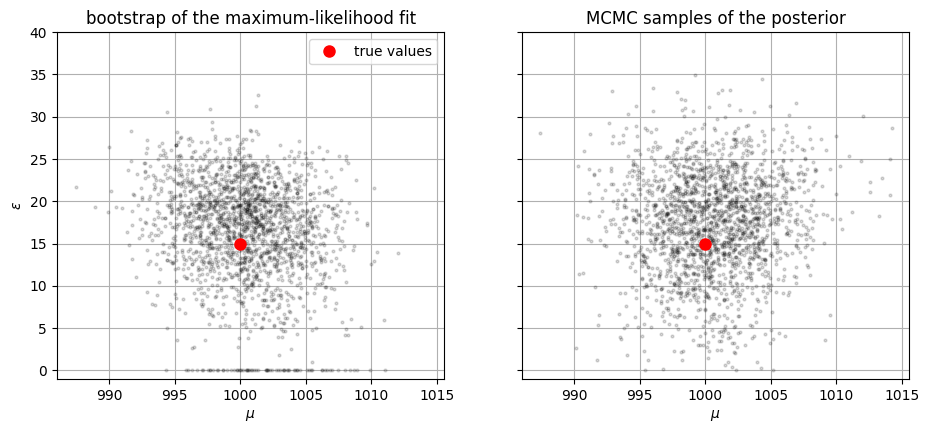

In [10]:
B = 2000
theta_boot = np.zeros((B, 2))
for b in range(B):
    idx = rng.integers(0, N, size=N)
    theta_boot[b] = optimize.minimize(lambda th: -log_likelihood(th, y[idx], sigma_y[idx]),
                                      x0=theta_ml, method="Nelder-Mead").x
theta_boot[:, 1] = np.abs(theta_boot[:, 1])      # the likelihood only depends on eps^2; fold negative solutions back

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, smp, title in zip(axs, [theta_boot, samples[:len(theta_boot)]], ["bootstrap of the maximum-likelihood fit", "MCMC samples of the posterior"]):
    ax.plot(smp[:, 0], smp[:, 1], ".k", alpha=0.15, ms=4)
    ax.plot(mu_true, eps_true, "o", color="red", ms=8, label="true values")
    ax.set_title(title); ax.set_xlabel(r"$\mu$")
axs[0].set_ylabel(r"$\epsilon$"); axs[0].legend(); axs[0].set_ylim(-1, 40)
for name, i in [("mu", 0), ("eps", 1)]:
    lo, med, hi = np.percentile(theta_boot[:, i], [15.9, 50, 84.1])
    print(f"bootstrap {name:3s} = {med:7.1f} -{med-lo:.1f} +{hi-med:.1f}")

The two clouds look alike, and the 68% intervals agree. The differences are conceptual as much as practical. The bootstrap describes the *distribution of the estimator* over hypothetical repetitions of the experiment; a bootstrap sample with $\epsilon$ at zero is an artefact of a resampled dataset in which the fit found no scatter. The MCMC samples describe *our knowledge of the parameters given this dataset*, including the prior $\epsilon \geq 0$. The bootstrap needed 2000 maximum-likelihood fits (about ten seconds); `emcee` produced tens of thousands of samples in the same time and needs no fitting at all. And only the posterior samples can be used for marginalization, error propagation and model comparison in the Bayesian sense. Bootstrap is often listed as a frequentist technique, but in practice it is not far from Bayesian sampling with flat priors; when the two disagree, look for a boundary in parameter space or a non-Gaussian likelihood.

## 6.7 MCMC checklist

1. Write the log-posterior as log-prior + log-likelihood, returning $-\infty$ outside the prior. Test it on a few values before sampling.
2. Start the walkers in a small ball around a sensible point (the least-squares or maximum-likelihood solution), or spread them uniformly over the prior if you suspect multiple modes.
3. Run, and **look at the chains**. Are they stationary? Did all walkers converge to the same region?
4. Discard the **burn-in** (by eye, or a few autocorrelation times). Discard **rogue walkers** with an anomalous acceptance fraction.
5. Check the **autocorrelation time**; run at least $\sim 50\tau$ steps, thin if you like.
6. Make the **corner plot**. Look for correlations, multiple modes, walkers piling up at a prior boundary.
7. Report medians and equal-tailed credible intervals (or upper limits), and keep the samples for error propagation.

## 6.8 Test yourself

````{admonition} Q1. Cutting chains (practice exam)
:class: tip
You ran 100 chains for 1000 steps. The trace plot shows all chains starting at 0.7, spreading out over the first 200 steps, and then fluctuating around 0.6; a handful of chains, however, wander off to values near 0.1–0.3 and stay there. (a) How would you cut or slice this collection of chains before using it for inference? (b) How do you estimate the credible interval of the parameter from the remaining samples?

```{admonition} Answer
:class: dropdown
(a) Remove the burn-in phase, here roughly the first 250–300 steps, during which the chains are still moving towards equilibrium. Remove the chains that did not converge; they can be identified by their anomalous (usually low) acceptance fraction, or simply by their position. (b) Collect the remaining samples; they represent the posterior. For a 68% interval either take the 16th and 84th percentiles (`np.percentile(samples, [16, 84])`), or sort the samples and find the shortest range that contains 68% of them. Alternatively report the mean and standard deviation of the samples as a Gaussian approximation. A histogram of the samples with the interval indicated is a good way to present this.
```
````

````{admonition} Q2. Complete the code (STAN exam 2023)
:class: tip
The function below implements one Metropolis–Hastings step for a parameter `mu` given data `y` and a function `loglike(y, mu)`; flat priors are implicit. Fill in the two missing pieces. Then explain why, in most MCMC applications, we have to discard some samples of each chain, and how to select the relevant part.

```python
def metro_hasting_step(mu, y, loglike, sigma_proposal=1):
    R_uni = np.random.rand()                     # uniform in [0, 1]
    current_loglike = loglike(y, mu)
    proposal_mu = mu + np.random.normal(0, sigma_proposal)
    proposal_loglike = loglike(y, proposal_mu)
    ratio = np.exp(proposal_loglike - current_loglike)
    if ____:
        return ____
    else:
        return mu
```

```{admonition} Answer
:class: dropdown
`if ratio > R_uni:` and `return proposal_mu`. We discard the burn-in: at the start the chain is still moving from its starting point towards the peak of the posterior, so those samples are not drawn from the posterior and would distort histograms and corner plots. Burn-in is over when the chain values as a function of step have flattened out (or after a few autocorrelation times); use only the samples after that.
```
````

## Sources and further reading

* Foreman-Mackey, Hogg, Lang & Goodman (2013), *emcee: The MCMC Hammer*, PASP 125, 306, [arXiv:1202.3665](https://arxiv.org/abs/1202.3665); and the [emcee documentation](https://emcee.readthedocs.io), in particular the *Fitting a model to data* tutorial that the assignment builds on.
* Goodman & Weare (2010), *Ensemble samplers with affine invariance*, Comm. App. Math. Comp. Sci. 5, 65.
* Gelman et al., *Bayesian Data Analysis* (3rd ed.), Chapter 11 (Metropolis–Hastings, convergence diagnostics).
* Hogg & Foreman-Mackey (2018), *Data analysis recipes: Using Markov Chain Monte Carlo*, ApJS 236, 11, [arXiv:1710.06068](https://arxiv.org/abs/1710.06068), a practical guide in the spirit of Hogg et al. (2010).
* Budd (2024), *Monte Carlo Techniques* (Radboud lecture notes), chapter on MCMC, for the mathematics of Markov chains and detailed balance.